# Cleared for Launch: AI Governance Assessment
## ClinicalCompanion — MedAssist AI

**Course:** Data Governance for Generative AI (cd13873)

---

### Scenario

You are an **AI Governance Analyst at MedAssist AI**, preparing **ClinicalCompanion** — a generative AI clinical decision support system — for EU market launch within 3 months. Your manager needs a governance assessment before the board meeting next week.

### Your Deliverables

You will produce **two files** that together cover all six governance deliverables:

| # | Deliverable | Notebook (code + analysis) | Workbook (written analysis) |
|---|---|---|---|
| 1 | EU AI Act Classification | Compliance gap analysis | Classification reasoning + gap table |
| 2 | Risk Register + Heatmap | **Risk heatmap visualization** | Risk details + mitigations |
| 3 | Vendor Evaluation | Vendor scorecard visualization | Evaluation narrative + recommendation |
| 4 | Model Card | Disaggregated performance chart | Model Card content |
| 5 | Monitoring & Incident Response | Monitoring dashboard | KPI definitions + incident plan |
| 6 | Executive Summary | Executive readiness dashboard | Board-ready narrative |

### Project Structure

```
starter/
├── data/                          ← Input datasets (provided — do not modify)
│   ├── system_spec.json           ← ClinicalCompanion system specification
│   ├── training_data_summary.csv  ← Training data sources
│   ├── performance_metrics.csv    ← Model performance by subgroup
│   ├── risk_register.csv          ← Risk register (NIST AI RMF)
│   ├── vendor_assessment.csv      ← Vendor evaluation criteria + scores
│   ├── vendor_profile.json        ← Vendor company profile
│   ├── eu_ai_act_requirements.csv ← EU AI Act compliance requirements
│   ├── monitoring_kpis.csv        ← Monitoring KPI definitions
│   ├── incident_types.csv         ← Incident taxonomy
│   └── severity_levels.csv        ← Incident severity definitions
├── results/                       ← Your outputs will be saved here
├── governance_assessment.ipynb    ← THIS NOTEBOOK (code deliverable)
└── governance_workbook.xlsx       ← Written deliverable (fill in the 6 sheets)
```

### How to Work Through This Notebook

1. Read each step's instructions carefully
2. Look for **🔧 TODO** markers — these are where you write code
3. Run your code and verify the outputs make sense
4. Save all visualizations to `results/`
5. Use insights from your analysis to fill in `governance_workbook.xlsx`

**Estimated time: ~3.5 hours** (notebook) + **~1.5 hours** (workbook) = **5 hours total**

---
## Step 0: Environment Setup

Run this cell to set up your environment. **No changes needed here.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from pathlib import Path

# Paths
DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# Display settings
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Environment ready.")
print(f"Data directory:    {DATA_DIR.resolve()}")
print(f"Results directory:  {RESULTS_DIR.resolve()}")

Environment ready.
Data directory:    /home/architect/ai_governance_assessement/project/starter/data
Results directory:  /home/architect/ai_governance_assessement/project/starter/results


---
## Step 1: Load and Explore the ClinicalCompanion System Specification

**Time estimate: ~20 minutes**

Your first task as a governance analyst is to understand the system you're assessing. Load the system specification and training data summary, then extract the key facts that will inform your governance assessment.

**Key questions to answer:**
- What type of AI system is this? Who uses it?
- What foundation model powers it and how is it accessed?
- What data was it trained on and where does it come from?
- What is the deployment timeline and regulatory status?

### 1a. Load and display the system overview

🔧 **TODO:** Load `system_spec.json` and print a formatted overview of the system. Include at minimum:
- System name, version, type
- Foundation model name, parameters, access method
- Cloud region and security (encryption)
- Target launch date

*Hint: Use `json.load()` to read the file, then access nested keys like `spec['system']['name']`*

In [2]:
# Step 1a: Load and display system overview

# Load the system specification JSON
with open(DATA_DIR / 'system_spec.json') as f:
    spec = json.load(f)

# Print a formatted header
print("=" * 70)
print("CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW")
print("=" * 70)

# Key system facts pulled from the nested spec structure
fm = spec['architecture']['foundation_model']
infra = spec['architecture']['infrastructure']
overview = {
    'System': f"{spec['system']['name']} v{spec['system']['version']}",
    'Type': spec['system']['type'],
    'Developer': spec['system']['developer'],
    'Foundation Model': fm['model_name'],
    'Parameters': fm['parameters'],
    'Access Method': fm['access_method'],
    'Cloud Region': f"{infra['cloud_provider']} {infra['region']}",
    'Encryption': f"{infra['encryption_at_rest']} at rest / {infra['encryption_in_transit']} in transit",
    'Target Launch Date': spec['system']['release_date_planned'],
}

for fact, value in overview.items():
    print(f"{fact:<20}: {value}")


CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW
System              : ClinicalCompanion v1.0
Type                : Clinical Decision Support System (CDSS)
Developer           : MedAssist AI
Foundation Model    : FoundationHealth Medical LLM v3.2
Parameters          : 7B
Access Method       : API
Cloud Region        : AWS eu-west-1 (Frankfurt)
Encryption          : AES-256 at rest / TLS 1.3 in transit
Target Launch Date  : 2025-09-01


### 1b. Display intended users and out-of-scope uses

🔧 **TODO:** From the system spec, print:
1. The list of **intended users** (who is allowed to use this system?)
2. The list of **out-of-scope uses** (what is this system NOT for?)

*Think about: Why do these matter for governance? How do they affect risk classification?*

In [3]:
# Step 1b: Print intended users and out-of-scope uses

print("INTENDED USERS:")
for user in spec['intended_use']['intended_users']:
    print(f"  • {user}")

print("\nOUT-OF-SCOPE USES:")
for use in spec['intended_use']['out_of_scope']:
    print(f"  ✗ {use}")


INTENDED USERS:
  • Licensed physicians (primary care and specialists)
  • Clinical fellows and residents (under attending supervision)
  • Nurse practitioners and physician assistants (where authorized)

OUT-OF-SCOPE USES:
  ✗ Autonomous diagnosis or treatment decisions
  ✗ Standalone diagnostic tool (must not replace physician judgment)
  ✗ Patient-facing interface (no direct patient use)
  ✗ Pediatric populations (under 18) in initial release
  ✗ Emergency triage as sole decision-making tool


### 1c. Load and explore training data sources

🔧 **TODO:** Load `training_data_summary.csv` and display:
1. A table of all training data sources with their record counts and geography
2. The total number of training records

*Think about: What geographic gaps do you see? How might this affect fairness?*

In [4]:
# Step 1c: Load and display training data summary

training_df = pd.read_csv(DATA_DIR / 'training_data_summary.csv')

print("=" * 70)
print("TRAINING DATA SOURCES")
print("=" * 70)

print(training_df[['source_name', 'record_count', 'geography', 'data_type']]
      .to_string(index=False))

total_records = training_df['record_count'].sum()
print(f"\nTotal training records: {total_records:,}")


TRAINING DATA SOURCES
                    source_name  record_count                    geography                    data_type
Partner Hospital Network A (EU)        280000 Germany, France, Netherlands               EHR encounters
Partner Hospital Network B (US)        170000  United States (multi-state)               EHR encounters
         PubMed Abstract Corpus       2100000                       Global Medical literature abstracts
            Expert Clinical Q&A         12000                       EU, US            Curated Q&A pairs
   Clinical Practice Guidelines           340                  EU, US, WHO          Practice guidelines

Total training records: 2,562,340


---
## Step 2: EU AI Act Risk Classification

**Time estimate: ~45 minutes**

This is one of the most important governance tasks. You need to walk through the EU AI Act's classification framework and determine ClinicalCompanion's risk level. Then analyze compliance gaps.

**EU AI Act Classification Decision Tree:**
1. **Article 5 — Prohibited practices?** (social scoring, exploitation, subliminal manipulation, real-time biometric ID)
2. **Article 6(1) — Safety component under EU harmonisation legislation?** (check if it falls under MDR, machinery, toys, etc.)
3. **Annex III — High-risk use cases?** (biometric ID, critical infrastructure, education, employment, essential services, law enforcement, migration, justice)
4. If none of the above → Limited risk or minimal risk

### 2a. Prohibited practices check

🔧 **TODO:** For each prohibited practice under Article 5, evaluate whether ClinicalCompanion engages in it. Print a clear pass/fail for each one with a brief justification.

*The four prohibited categories are: social scoring, exploiting vulnerabilities, real-time remote biometric identification, and subliminal manipulation.*

In [5]:
# Step 2a: Evaluate Article 5 prohibited practices

print("STEP 1: Prohibited Practices Check (Article 5)")
print("-" * 50)

# The four prohibited categories to check against
prohibited_practices = [
    "Social scoring by public authorities",
    "Exploiting vulnerabilities",
    "Real-time remote biometric identification",
    "Subliminal manipulation"
]

justifications = {
    "Social scoring by public authorities":
        "System supports clinical diagnosis for physicians; it does not score or rank citizens for public authorities.",
    "Exploiting vulnerabilities":
        "Tool is restricted to licensed clinicians; it is not patient-facing and does not target vulnerable groups.",
    "Real-time remote biometric identification":
        "System processes de-identified EHR text only; no biometric data or identification capability.",
    "Subliminal manipulation":
        "Suggestions are transparent, ranked, and carry confidence scores; every output requires active physician review.",
}

for practice in prohibited_practices:
    print(f"  ✅ PASS — {practice}")
    print(f"      {justifications[practice]}")

print("\nCONCLUSION: ClinicalCompanion engages in NONE of the Article 5 prohibited")
print("practices → NOT PROHIBITED. Proceed to high-risk classification (Article 6).")


STEP 1: Prohibited Practices Check (Article 5)
--------------------------------------------------
  ✅ PASS — Social scoring by public authorities
      System supports clinical diagnosis for physicians; it does not score or rank citizens for public authorities.
  ✅ PASS — Exploiting vulnerabilities
      Tool is restricted to licensed clinicians; it is not patient-facing and does not target vulnerable groups.
  ✅ PASS — Real-time remote biometric identification
      System processes de-identified EHR text only; no biometric data or identification capability.
  ✅ PASS — Subliminal manipulation
      Suggestions are transparent, ranked, and carry confidence scores; every output requires active physician review.

CONCLUSION: ClinicalCompanion engages in NONE of the Article 5 prohibited
practices → NOT PROHIBITED. Proceed to high-risk classification (Article 6).


### 2b. High-risk classification

🔧 **TODO:** Determine whether ClinicalCompanion qualifies as HIGH-RISK. Consider:

1. **Is it a safety component under EU harmonisation legislation?** (Article 6(1))
   - Is ClinicalCompanion a medical device under MDR 2017/745?
   - If yes, what MDR class would it be? (Class I, IIa, IIb, or III?)

2. **Does it fall under Annex III high-risk use cases?**

Print your classification with the legal basis (which Article and Annex).

*Hint: A clinical decision support system that assists physicians with diagnoses falls under medical device regulation.*

In [6]:
# Step 2b: Walk through the high-risk classification decision tree

print("STEP 2: Safety Component Under EU Harmonisation Legislation?")
print("-" * 50)

print("""Q1. Is it a medical device under MDR 2017/745?
    → YES. ClinicalCompanion is software intended to provide information used
      for diagnostic purposes (diagnostic suggestions to physicians), which
      meets the MDR definition of a medical device (software as a medical device).

Q2. What MDR class?
    → Class IIa under MDR Rule 11: software providing information used to take
      decisions with diagnostic or therapeutic purposes. (Physician-in-the-loop
      design keeps it below Class IIb/III thresholds for decisions that could
      directly cause death or irreversible deterioration.)

Q3. Does it require a conformity assessment?
    → YES. Class IIa requires a Notified Body conformity assessment and CE
      marking before being placed on the EU market. Status: application
      submitted, awaiting Notified Body review.""")

print("\nSTEP 3: Annex III High-Risk Use Cases?")
print("-" * 50)
annex_iii = ["Biometric identification", "Critical infrastructure", "Education",
             "Employment", "Essential services", "Law enforcement",
             "Migration/asylum/border", "Administration of justice"]
for cat in annex_iii:
    print(f"  ✗ {cat}: does not apply — clinical decision support is not listed")
print("  → Not an Annex III system; classification is driven by Article 6(1) instead.")

print("\n" + "=" * 70)
print("FINAL CLASSIFICATION: HIGH-RISK AI SYSTEM")
print("=" * 70)
print("""Legal basis: Article 6(1) EU AI Act — the system is a product (medical
device, MDR 2017/745 Class IIa) covered by Annex I harmonisation legislation
and subject to third-party conformity assessment. All high-risk obligations
under Articles 8-15 therefore apply in full.""")


STEP 2: Safety Component Under EU Harmonisation Legislation?
--------------------------------------------------
Q1. Is it a medical device under MDR 2017/745?
    → YES. ClinicalCompanion is software intended to provide information used
      for diagnostic purposes (diagnostic suggestions to physicians), which
      meets the MDR definition of a medical device (software as a medical device).

Q2. What MDR class?
    → Class IIa under MDR Rule 11: software providing information used to take
      decisions with diagnostic or therapeutic purposes. (Physician-in-the-loop
      design keeps it below Class IIb/III thresholds for decisions that could
      directly cause death or irreversible deterioration.)

Q3. Does it require a conformity assessment?
    → YES. Class IIa requires a Notified Body conformity assessment and CE
      marking before being placed on the EU market. Status: application
      submitted, awaiting Notified Body review.

STEP 3: Annex III High-Risk Use Cases?
------

### 2c. Compliance gap analysis

🔧 **TODO:** Load `eu_ai_act_requirements.csv` and analyze the compliance gaps:
1. Print each requirement with its current status and severity
2. Calculate and print a summary: how many Critical, High, Medium, Low gaps exist?

*Use emoji or symbols to make the status easy to scan (e.g., ✅ Compliant, ⚠️ Partial, 🔶 In Progress)*

*Think about: Which gaps are most urgent? What's the critical path to compliance?*

In [7]:
# Step 2c: Load and analyze EU AI Act compliance requirements

compliance_df = pd.read_csv(DATA_DIR / 'eu_ai_act_requirements.csv')

print("COMPLIANCE REQUIREMENTS (Articles 8-15):")
print("-" * 70)

status_icons = {
    'Compliant': '✅',
    'In Progress': '🔶',
    'Partial': '⚠️',
    'Planned': '📋',
    'Not Started': '❌',
}

for _, row in compliance_df.iterrows():
    icon = status_icons.get(row['current_status'], '❓')
    print(f"{icon} {row['article']:<11} {row['requirement_name']:<28} "
          f"status: {row['current_status']:<12} severity: {row['severity']}")

print("\nGAP SUMMARY:")
severity_counts = compliance_df['severity'].value_counts()
for sev in ['Critical', 'High', 'Medium', 'Low']:
    print(f"  {sev:<9}: {severity_counts.get(sev, 0)}")
print(f"  Total requirements assessed: {len(compliance_df)}")


COMPLIANCE REQUIREMENTS (Articles 8-15):
----------------------------------------------------------------------
⚠️ Article 9   Risk Management System       status: Partial      severity: High
🔶 Article 9   Risk Identification          status: In Progress  severity: Medium
❌ Article 9   Residual Risk Evaluation     status: Not Started  severity: High
⚠️ Article 10  Data Governance              status: Partial      severity: High
⚠️ Article 10  Dataset Representativeness   status: Partial      severity: High
🔶 Article 10  Special Category Data        status: In Progress  severity: Medium
🔶 Article 11  Technical Documentation      status: In Progress  severity: Medium
⚠️ Article 12  Record-Keeping               status: Partial      severity: Medium
📋 Article 12  Log Retention                status: Planned      severity: Medium
⚠️ Article 13  Transparency                 status: Partial      severity: Medium
🔶 Article 13  Instructions for Use         status: In Progress  severity: Medium


---
## Step 3: Risk Assessment (NIST AI RMF)

**Time estimate: ~30 minutes**

Load the risk register and analyze the 8 identified risks. The risks are organized by NIST AI RMF functions (Govern, Map, Measure, Manage).

**Key analysis tasks:**
- Load and display the risk register
- Calculate summary statistics (average score, max score, priority distribution)
- Identify which NIST functions have the most risk concentration
- Compare pre-mitigation vs. post-mitigation scores to assess effectiveness

### 3a. Load and summarize the risk register

🔧 **TODO:** Load `risk_register.csv` and display:
1. A summary table showing: risk_id, category, NIST function, likelihood, impact, risk score, priority
2. Key statistics: total risks, count by priority (Critical/High/Medium), average and max scores

*Hint: The risk_score column = likelihood × impact (5×5 scale, max 25)*

In [8]:
# Step 3a: Load risk register and display summary

risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

print("=" * 70)
print("RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)")
print("=" * 70)

summary_cols = ['risk_id', 'risk_category', 'nist_rmf_function',
                'likelihood', 'impact', 'risk_score', 'priority']
print(risk_df[summary_cols].to_string(index=False))

# Derive priority bands from the scoring guide (Critical 20-25, High 15-19)
critical_count = (risk_df['risk_score'] >= 20).sum()
high_count = risk_df['risk_score'].between(15, 19).sum()

print(f"\n{'─' * 40}")
print(f"Total risks          : {len(risk_df)}")
print(f"Critical (score 20-25): {critical_count}")
print(f"High (score 15-19)    : {high_count}")
print(f"Average risk score    : {risk_df['risk_score'].mean():.1f}")
print(f"Maximum risk score    : {risk_df['risk_score'].max()}")


RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)
risk_id      risk_category nist_rmf_function  likelihood  impact  risk_score priority
  R-001          Technical           Measure           4       5          20 Critical
  R-002     Ethical / Bias               Map           4       4          16     High
  R-003 Legal / Regulatory            Govern           3       5          15     High
  R-004 Privacy / Security            Manage           3       5          15     High
  R-005        Operational            Manage           3       4          12     High
  R-006          Technical           Measure           3       4          12     High
  R-007   Ethical / Safety               Map           3       5          15     High
  R-008 Legal / Regulatory            Govern           3       5          15     High

────────────────────────────────────────
Total risks          : 8
Critical (score 20-25): 1
High (score 15-19)    : 5
Average risk score    : 15.0
Maximum risk score    : 2

### 3b. Analyze risk distribution by NIST AI RMF function

🔧 **TODO:** Group the risks by their `nist_rmf_function` and calculate:
- Number of risks per function
- Average risk score per function
- Which function carries the highest total risk?

*The four NIST AI RMF functions are: Govern, Map, Measure, Manage*

In [9]:
# Step 3b: Analyze risks by NIST AI RMF function

# The four NIST AI RMF functions: Govern, Map, Measure, Manage
rmf_summary = (risk_df.groupby('nist_rmf_function')
               .agg(num_risks=('risk_id', 'count'),
                    avg_score=('risk_score', 'mean'),
                    total_score=('risk_score', 'sum'))
               .round(1)
               .sort_values('total_score', ascending=False))

print("RISKS BY NIST AI RMF FUNCTION:")
print(rmf_summary.to_string())

top_function = rmf_summary['total_score'].idxmax()
print(f"\n→ The '{top_function}' function carries the highest total risk "
      f"({rmf_summary.loc[top_function, 'total_score']:.0f} points across "
      f"{rmf_summary.loc[top_function, 'num_risks']:.0f} risks).")


RISKS BY NIST AI RMF FUNCTION:
                   num_risks  avg_score  total_score
nist_rmf_function                                   
Measure                    2       16.0           32
Map                        2       15.5           31
Govern                     2       15.0           30
Manage                     2       13.5           27

→ The 'Measure' function carries the highest total risk (32 points across 2 risks).


### 3c. Mitigation effectiveness analysis

🔧 **TODO:** Compare pre-mitigation scores vs. post-mitigation (residual) scores:
1. For each risk, calculate the percentage reduction
2. Print the total pre-mitigation score, total post-mitigation score, and overall reduction %
3. Which risk has the largest absolute reduction? Which has the smallest?

*This analysis will feed into the risk heatmap you'll create next.*

In [10]:
# Step 3c: Analyze mitigation effectiveness

risk_df['reduction_pct'] = ((risk_df['risk_score'] - risk_df['residual_score'])
                            / risk_df['risk_score'] * 100)

print("MITIGATION EFFECTIVENESS BY RISK:")
print("-" * 60)
for _, r in risk_df.iterrows():
    print(f"  {r['risk_id']}: {r['risk_score']:>2} → {r['residual_score']:>2}  "
          f"({r['reduction_pct']:.1f}% reduction)")

total_pre = risk_df['risk_score'].sum()
total_post = risk_df['residual_score'].sum()
overall_reduction = (total_pre - total_post) / total_pre * 100

best = risk_df.loc[risk_df['reduction_pct'].idxmax()]
worst = risk_df.loc[risk_df['reduction_pct'].idxmin()]

print("-" * 60)
print(f"Total pre-mitigation score : {total_pre}")
print(f"Total post-mitigation score: {total_post}")
print(f"Overall reduction          : {overall_reduction:.1f}%")
print(f"Largest reduction          : {best['risk_id']} ({best['reduction_pct']:.1f}%)")
print(f"Smallest reduction         : {worst['risk_id']} ({worst['reduction_pct']:.1f}%)")


MITIGATION EFFECTIVENESS BY RISK:
------------------------------------------------------------
  R-001: 20 → 10  (50.0% reduction)
  R-002: 16 →  8  (50.0% reduction)
  R-003: 15 →  5  (66.7% reduction)
  R-004: 15 → 10  (33.3% reduction)
  R-005: 12 →  8  (33.3% reduction)
  R-006: 12 →  6  (50.0% reduction)
  R-007: 15 →  8  (46.7% reduction)
  R-008: 15 →  8  (46.7% reduction)
------------------------------------------------------------
Total pre-mitigation score : 120
Total post-mitigation score: 63
Overall reduction          : 47.5%
Largest reduction          : R-003 (66.7%)
Smallest reduction         : R-004 (33.3%)


---
## Step 4: Risk Heatmap Visualization

**Time estimate: ~40 minutes**

This is the main visualization deliverable. Create a professional risk heatmap that maps the 8 risks on a 5×5 likelihood × impact matrix, plus a companion chart showing risk scores.

**Requirements:**
- 5×5 grid with color gradient (green→yellow→orange→red)
- Each risk plotted at its (likelihood, impact) position
- Risk IDs labeled on each point
- Critical risks visually distinguished (different marker)
- A second chart showing risk scores as horizontal bars

### 4a. Create the risk heatmap

🔧 **TODO:** Create a figure with two subplots side-by-side:

**Left panel — 5×5 Risk Heatmap:**
- Background colored by risk score (likelihood × impact) using a green-to-red colormap
- White grid lines separating cells
- Each risk plotted as a scatter point at its (likelihood-1, impact-1) position (0-indexed)
- Critical risks: square markers, larger size
- High risks: circle markers
- Risk IDs annotated near each point
- Risk score numbers faintly visible in each cell
- Axis labels: "Likelihood →" and "Impact →" with descriptive tick labels
- Legend showing risk level color bands

**Right panel — Risk Score Bar Chart:**
- Horizontal bars showing each risk's score
- Colored by priority (Critical = darker red)
- Risk scores labeled on each bar
- Reference lines at score 10 and 15

Save as `results/risk_heatmap.png` with `dpi=150`.

*Hints:*
- *Use `plt.subplots(1, 2, figsize=(20, 8))` for side-by-side layout*
- *Use `imshow()` for the heatmap background*
- *Use `scatter()` to plot individual risks*
- *Use `annotate()` to label risk IDs*

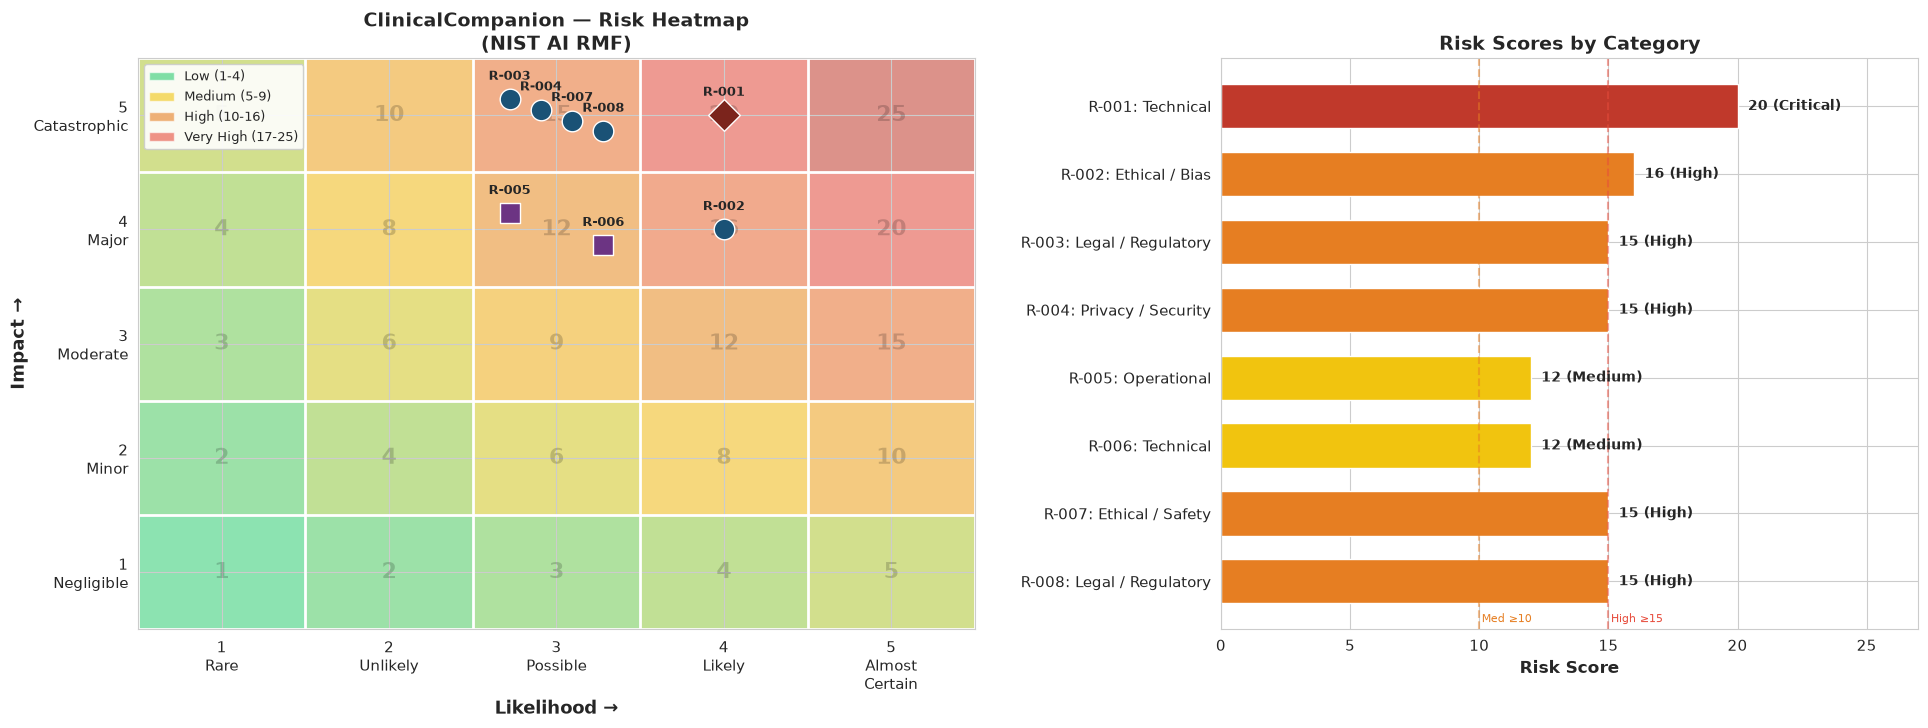

✅ Saved: results/risk_heatmap.png


In [11]:
# Step 4a: Create the risk heatmap visualization
from matplotlib.colors import LinearSegmentedColormap

# Re-load risk data (in case you modified risk_df above)
risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8),
                                gridspec_kw={'width_ratios': [1.2, 1]})

# --- LEFT PANEL: 5×5 Risk Heatmap ---

# Score matrix for background coloring (each cell = likelihood × impact)
score_matrix = np.array([[(i+1)*(j+1) for j in range(5)] for i in range(5)])

# Color gradient: green (low risk) → red (high risk)
cmap = LinearSegmentedColormap.from_list('risk',
       ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b'], N=256)

# Heatmap background: likelihood on x, impact on y, (1,1) at bottom-left
ax1.imshow(score_matrix, cmap=cmap, origin='lower', alpha=0.55,
           vmin=1, vmax=25, extent=(-0.5, 4.5, -0.5, 4.5), aspect='auto')

# White grid lines separating cells
for g in np.arange(-0.5, 5.0, 1.0):
    ax1.axhline(g, color='white', lw=2)
    ax1.axvline(g, color='white', lw=2)

# Plot each risk at (likelihood-1, impact-1), offsetting overlapping points
style = {'Critical': dict(marker='D', s=260, c='#7b241c', edgecolors='white'),
         'High':     dict(marker='o', s=220, c='#1a5276', edgecolors='white'),
         'Medium':   dict(marker='s', s=200, c='#6c3483', edgecolors='white')}
band = lambda s: 'Critical' if s >= 20 else ('High' if s >= 15 else 'Medium')

plotted = set()
for (lik, imp), group in risk_df.groupby(['likelihood', 'impact']):
    n = len(group)
    offsets = np.linspace(-0.28, 0.28, n) if n > 1 else [0.0]
    for off, (_, r) in zip(offsets, group.iterrows()):
        x, y = r['likelihood'] - 1 + off, r['impact'] - 1 - off * 0.5
        b = band(r['risk_score'])
        label = f"{b} priority" if b not in plotted else None
        plotted.add(b)
        ax1.scatter(x, y, zorder=5, label=label, **style[b])
        ax1.annotate(r['risk_id'], (x, y), xytext=(0, 14),
                     textcoords='offset points', ha='center',
                     fontsize=9, fontweight='bold', zorder=6)

# Faint score numbers in each cell center (L×I value)
for i in range(5):        # impact (rows)
    for j in range(5):    # likelihood (cols)
        ax1.text(j, i, str(score_matrix[i, j]), ha='center', va='center',
                 fontsize=16, color='black', alpha=0.18, fontweight='bold')

# Axis labels and formatting (provided)
ax1.set_xlabel('Likelihood →', fontsize=13, fontweight='bold')
ax1.set_ylabel('Impact →', fontsize=13, fontweight='bold')
ax1.set_title('ClinicalCompanion — Risk Heatmap\n(NIST AI RMF)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(5))
ax1.set_xticklabels(['1\nRare','2\nUnlikely','3\nPossible','4\nLikely','5\nAlmost\nCertain'])
ax1.set_yticks(range(5))
ax1.set_yticklabels(['1\nNegligible','2\nMinor','3\nModerate','4\nMajor','5\nCatastrophic'])
ax1.legend(handles=[
    mpatches.Patch(fc='#2ecc71', alpha=0.6, label='Low (1-4)'),
    mpatches.Patch(fc='#f1c40f', alpha=0.6, label='Medium (5-9)'),
    mpatches.Patch(fc='#e67e22', alpha=0.6, label='High (10-16)'),
    mpatches.Patch(fc='#e74c3c', alpha=0.6, label='Very High (17-25)'),
], loc='upper left', fontsize=9, framealpha=0.9)


# --- RIGHT PANEL: Risk Score Bar Chart ---

bar_colors = {'Critical': '#c0392b', 'High': '#e67e22', 'Medium': '#f1c40f'}
colors = [bar_colors[band(s)] for s in risk_df['risk_score']]
ax2.barh(range(len(risk_df)), risk_df['risk_score'], color=colors,
         edgecolor='white', height=0.65)
for idx, (_, r) in enumerate(risk_df.iterrows()):
    ax2.text(r['risk_score'] + 0.4, idx, f"{r['risk_score']} ({band(r['risk_score'])})",
             va='center', fontsize=10, fontweight='bold')
ax2.axvline(x=15, color='#e74c3c', ls='--', alpha=0.5)
ax2.axvline(x=10, color='#e67e22', ls='--', alpha=0.5)
ax2.text(15.1, len(risk_df) - 0.4, 'High ≥15', fontsize=8, color='#e74c3c')
ax2.text(10.1, len(risk_df) - 0.4, 'Med ≥10', fontsize=8, color='#e67e22')

# Axis formatting (provided)
ax2.set_yticks(range(len(risk_df)))
ax2.set_yticklabels([f"{r['risk_id']}: {r['risk_category']}" for _, r in risk_df.iterrows()])
ax2.set_xlabel('Risk Score', fontsize=12, fontweight='bold')
ax2.set_title('Risk Scores by Category', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 27)
ax2.invert_yaxis()

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'risk_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/risk_heatmap.png")


### 4b. Create the pre vs. post-mitigation comparison chart

🔧 **TODO:** Create a grouped bar chart comparing pre-mitigation and post-mitigation risk scores:
- Side-by-side bars (red = pre, green = post) for each risk
- Score labels on top of each bar
- Percentage reduction annotated above each pair
- Reference lines at scores 10 and 15
- Save as `results/risk_mitigation_comparison.png`

*Hint: Use `np.arange()` for bar positions and offset by bar width/2 for grouping*

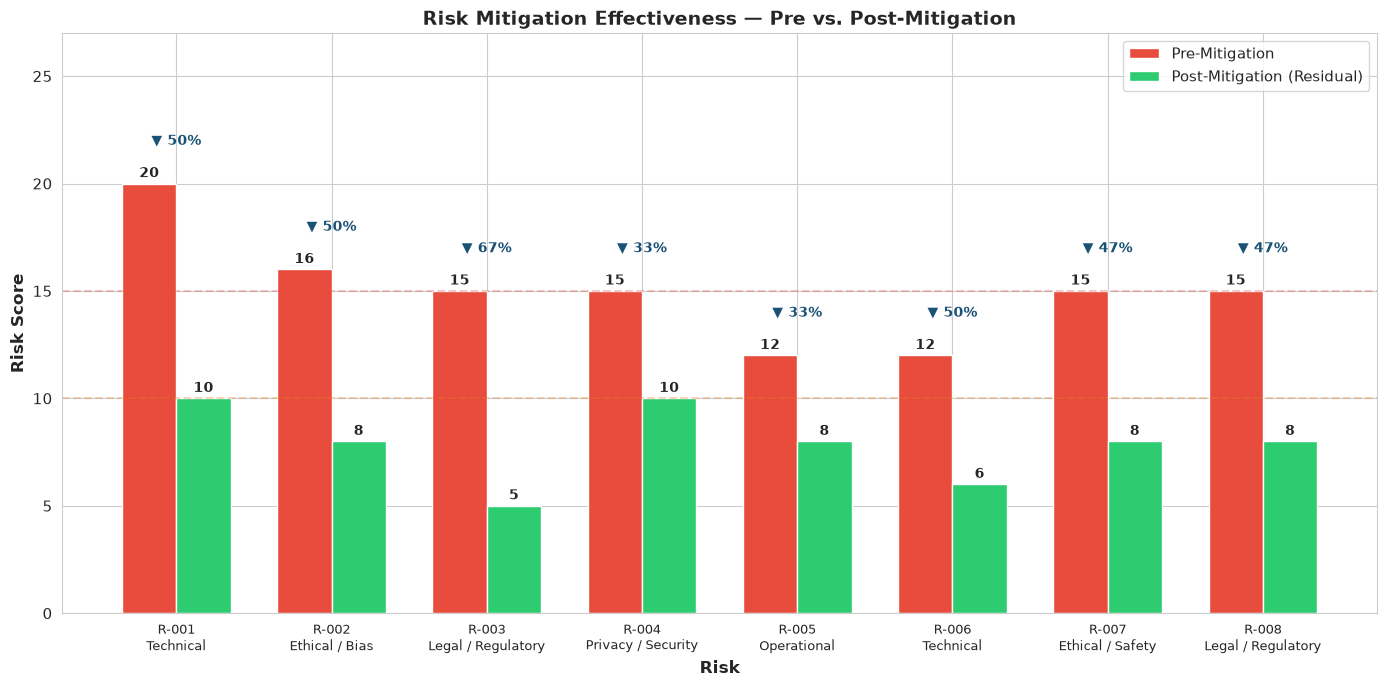

✅ Saved: results/risk_mitigation_comparison.png


In [12]:
# Step 4b: Create pre vs. post-mitigation comparison

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(risk_df))
w = 0.35  # bar width

pre_bars = ax.bar(x - w/2, risk_df['risk_score'], w,
                  color='#e74c3c', edgecolor='white', label='Pre-Mitigation')
post_bars = ax.bar(x + w/2, risk_df['residual_score'], w,
                   color='#2ecc71', edgecolor='white', label='Post-Mitigation (Residual)')

# Score labels on top of each bar
for bars in (pre_bars, post_bars):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f"{b.get_height():.0f}", ha='center', fontsize=10, fontweight='bold')

# Percentage reduction above each risk pair
for xi, (_, r) in zip(x, risk_df.iterrows()):
    reduction = (r['risk_score'] - r['residual_score']) / r['risk_score'] * 100
    ax.annotate(f"▼ {reduction:.0f}%", (xi, r['risk_score'] + 1.8),
                ha='center', fontsize=10, color='#1a5276', fontweight='bold')

# Axis formatting (provided)
ax.set_xlabel('Risk', fontsize=12, fontweight='bold')
ax.set_ylabel('Risk Score', fontsize=12, fontweight='bold')
ax.set_title('Risk Mitigation Effectiveness — Pre vs. Post-Mitigation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['risk_id']}\n{r['risk_category']}" for _, r in risk_df.iterrows()], fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, 27)
ax.axhline(y=15, color='#e74c3c', ls='--', alpha=0.3)
ax.axhline(y=10, color='#e67e22', ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'risk_mitigation_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/risk_mitigation_comparison.png")


---
## Step 5: Vendor Evaluation Visualization

**Time estimate: ~30 minutes**

Load the vendor assessment data and create a governance scorecard. The vendor (FoundationHealth Inc.) has been evaluated across 27 criteria in 5 categories.

*Full evaluation narrative goes in `governance_workbook.xlsx` → Sheet "Vendor Evaluation"*

### 5a. Load and analyze vendor data

🔧 **TODO:** Load `vendor_assessment.csv` and `vendor_profile.json`, then:
1. Calculate the score percentage for each category (score / max_score × 100)
2. Calculate the overall vendor score
3. Print a summary showing each category's score and the overall rating

*Scoring guide: ≥80% = Low Risk, 60-79% = Medium Risk, <60% = High Risk*

In [13]:
# Step 5a: Load and analyze vendor assessment data

vendor_df = pd.read_csv(DATA_DIR / 'vendor_assessment.csv')
with open(DATA_DIR / 'vendor_profile.json') as f:
    vendor = json.load(f)

# Category-level scores (keep the CSV's category order)
cat_scores = (vendor_df.groupby('category', sort=False)
              .agg(score=('score', 'sum'), max_score=('max_score', 'sum'))
              .reset_index())
cat_scores['pct'] = cat_scores['score'] / cat_scores['max_score'] * 100

def risk_level(pct):
    return 'Low Risk' if pct >= 80 else ('Medium Risk' if pct >= 60 else 'High Risk')

cat_scores['risk_level'] = cat_scores['pct'].apply(risk_level)

print("=" * 90)
print(f"VENDOR GOVERNANCE SCORECARD — {vendor['company']['name']}")
print("=" * 90)
for _, c in cat_scores.iterrows():
    print(f"  {c['category']:<38} {c['score']:>3}/{c['max_score']:<3} "
          f"({c['pct']:>5.1f}%)  → {c['risk_level']}")

overall_score = vendor_df['score'].sum()
overall_max = vendor_df['max_score'].sum()
overall_pct = overall_score / overall_max * 100
print("-" * 90)
print(f"  {'OVERALL VENDOR SCORE':<38} {overall_score:>3}/{overall_max:<3} "
      f"({overall_pct:>5.1f}%)  → {risk_level(overall_pct)}")


VENDOR GOVERNANCE SCORECARD — FoundationHealth Inc.
  Model Transparency & Documentation      15/25  ( 60.0%)  → Medium Risk
  Data Privacy & Security                 25/30  ( 83.3%)  → Low Risk
  Model Governance & Lifecycle            15/25  ( 60.0%)  → Medium Risk
  Contractual & Business Continuity       18/30  ( 60.0%)  → Medium Risk
  Regulatory & Ethical Alignment          15/25  ( 60.0%)  → Medium Risk
------------------------------------------------------------------------------------------
  OVERALL VENDOR SCORE                    88/135 ( 65.2%)  → Medium Risk


### 5b. Create vendor scorecard visualization

🔧 **TODO:** Create a figure with two subplots:

**Left — Horizontal bar chart:**
- One bar per vendor category showing score percentage
- Color-coded: green (≥80%), yellow (60-79%), red (<60%)
- Score labels showing "XX% (score/max)" on each bar
- Reference lines at 60% and 80%

**Right — Radar/spider chart:**
- Categories around the perimeter
- Score percentages as the radar values
- Reference circles at 60% and 80%

Save as `results/vendor_evaluation_chart.png`.

*Hint: For the radar chart, use `fig.add_subplot(122, polar=True)` and compute angles with `np.linspace(0, 2*np.pi, n, endpoint=False)`*

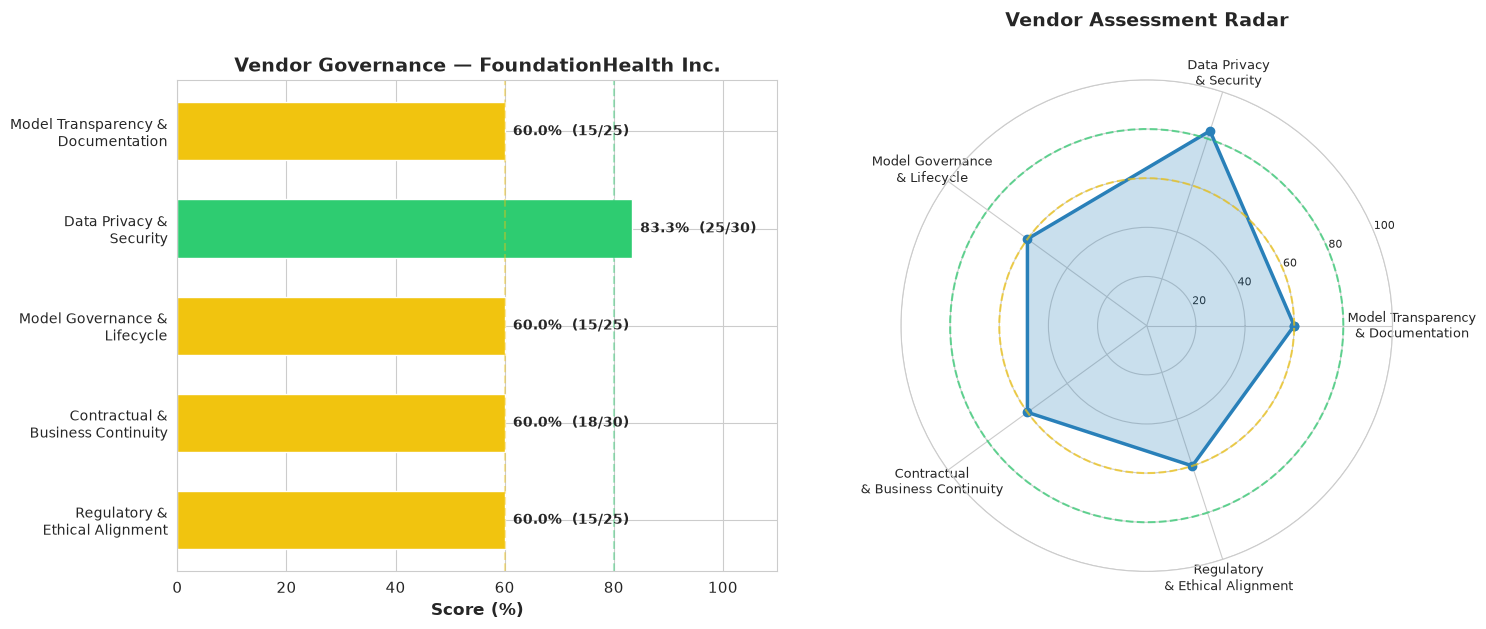

✅ Saved: results/vendor_evaluation_chart.png


In [14]:
# Step 5b: Create vendor scorecard visualization

fig, (ax1, ax2_placeholder) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Horizontal Bar Chart ---

def pct_color(p):
    return '#2ecc71' if p >= 80 else ('#f1c40f' if p >= 60 else '#e74c3c')

bar_colors = [pct_color(p) for p in cat_scores['pct']]
ax1.barh(range(len(cat_scores)), cat_scores['pct'], color=bar_colors,
         edgecolor='white', height=0.6)
ax1.set_yticks(range(len(cat_scores)))
ax1.set_yticklabels([c.replace(' & ', ' &\n') for c in cat_scores['category']], fontsize=10)
for idx, (_, c) in enumerate(cat_scores.iterrows()):
    ax1.text(c['pct'] + 1.5, idx, f"{c['pct']:.1f}%  ({c['score']:.0f}/{c['max_score']:.0f})",
             va='center', fontsize=10, fontweight='bold')

# Reference lines and formatting (provided)
ax1.set_xlabel('Score (%)', fontsize=12, fontweight='bold')
ax1.set_title(f"Vendor Governance — {vendor['company']['name']}", fontsize=14, fontweight='bold')
ax1.set_xlim(0, 110)
ax1.axvline(x=80, color='#2ecc71', ls='--', alpha=0.4)
ax1.axvline(x=60, color='#f1c40f', ls='--', alpha=0.4)
ax1.invert_yaxis()

# --- RIGHT PANEL: Radar/Spider Chart ---
ax2_placeholder.remove()  # Remove placeholder to create polar subplot
ax2 = fig.add_subplot(122, polar=True)

categories = cat_scores['category'].tolist()
values = cat_scores['pct'].tolist()
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()

# Close the polygon by repeating the first point
values_closed = values + [values[0]]
angles_closed = angles + [angles[0]]

ax2.plot(angles_closed, values_closed, color='#2980b9', lw=2.5, marker='o')
ax2.fill(angles_closed, values_closed, color='#2980b9', alpha=0.25)

# Reference circles at 60% (medium) and 80% (low risk)
circle = np.linspace(0, 2 * np.pi, 100)
ax2.plot(circle, [60] * 100, color='#f1c40f', ls='--', lw=1.5, alpha=0.7)
ax2.plot(circle, [80] * 100, color='#2ecc71', ls='--', lw=1.5, alpha=0.7)

ax2.set_xticks(angles)
ax2.set_xticklabels([c.replace(' & ', '\n& ') for c in categories], fontsize=9)
ax2.set_yticks([20, 40, 60, 80, 100])
ax2.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)

ax2.set_ylim(0, 100)
ax2.set_title('Vendor Assessment Radar\n', fontsize=14, fontweight='bold')

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'vendor_evaluation_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/vendor_evaluation_chart.png")


---
## Step 6: Model Card — Performance Analysis

**Time estimate: ~30 minutes**

Visualize disaggregated performance metrics for the Model Card fairness analysis. The Model Card framework (Mitchell et al., 2019) requires showing how the model performs across different subgroups, not just overall.

*Full Model Card content goes in `governance_workbook.xlsx` → Sheet "Model Card"*

### 6a. Analyze disaggregated performance

🔧 **TODO:** Load `performance_metrics.csv` and:
1. Filter for "Top-3 Diagnostic Accuracy" metrics across all subgroups
2. Identify which subgroups fall BELOW the 90% target
3. Print a summary of failing subgroups with their accuracy values

*Think about: What are the governance implications of these performance gaps? How do they relate to EU AI Act Article 10 (dataset representativeness)?*

In [15]:
# Step 6a: Load and analyze disaggregated performance metrics

perf_df = pd.read_csv(DATA_DIR / 'performance_metrics.csv')

# Top-3 Diagnostic Accuracy across all subgroups
accuracy_df = (perf_df[perf_df['metric_name'] == 'Top-3 Diagnostic Accuracy']
               .reset_index(drop=True))
print("TOP-3 DIAGNOSTIC ACCURACY BY SUBGROUP:")
print(accuracy_df[['subgroup', 'value', 'target', 'meets_target', 'sample_size']]
      .to_string(index=False))

# Subgroups below the 90% target
below_target = accuracy_df[accuracy_df['value'] < 90.0]
print("\n⚠️  SUBGROUPS BELOW THE 90% TARGET:")
for _, r in below_target.iterrows():
    print(f"  • {r['subgroup']:<22} {r['value']:.1f}%  "
          f"({90.0 - r['value']:.1f} pp below target, n={r['sample_size']:,})")

print("""
GOVERNANCE IMPLICATIONS (EU AI Act Article 10 — dataset representativeness):
  • Rare Diseases (71.2%) is 18.8 pp below target and 20.5 pp below the overall
    score (91.7%) — the clearest Article 10 representativeness gap; requires
    targeted training data for underrepresented conditions.
  • Multi-morbidity 4+ (74.0%) affects a large, clinically complex inpatient
    population — high patient-safety exposure.
  • Non-English Notes (84.3%) is critical for the DE/FR/NL launch markets —
    translation artifacts directly undermine the EU go-to-market.
  • Age 65+ (88.9%) is marginal but involves the demographic with the highest
    healthcare utilization — monitor via fairness KPIs.""")


TOP-3 DIAGNOSTIC ACCURACY BY SUBGROUP:
            subgroup  value target meets_target  sample_size
             Overall   91.7   90.0          Yes        45000
                Male   92.1   90.0          Yes        23400
              Female   91.3   90.0          Yes        21600
           Age 18-40   93.5   90.0          Yes        11200
           Age 41-64   92.0   90.0          Yes        19800
             Age 65+   88.9   90.0           No        14000
      Cardiovascular   94.1   90.0          Yes         8500
        Neurological   90.3   90.0          Yes         6200
       Rare Diseases   71.2   90.0           No         1035
   Non-English Notes   84.3   90.0           No         5400
Multi-morbidity (4+)   74.0   90.0           No         7650

⚠️  SUBGROUPS BELOW THE 90% TARGET:
  • Age 65+                88.9%  (1.1 pp below target, n=14,000)
  • Rare Diseases          71.2%  (18.8 pp below target, n=1,035)
  • Non-English Notes      84.3%  (5.7 pp below target, n=5,

### 6b. Create disaggregated performance bar chart

🔧 **TODO:** Create a bar chart showing Top-3 Diagnostic Accuracy by subgroup:
- One bar per subgroup
- Color-coded: green (≥90%), yellow (85-89%), orange (80-84%), red (<80%)
- The "Overall" bar highlighted with a distinct border
- Reference lines at 90%, 85%, and 80% thresholds
- Value labels on top of each bar
- Rotated x-axis labels for readability

Save as `results/model_card_performance.png`.

*Print a list of subgroups below the 85% threshold — these need mitigation.*

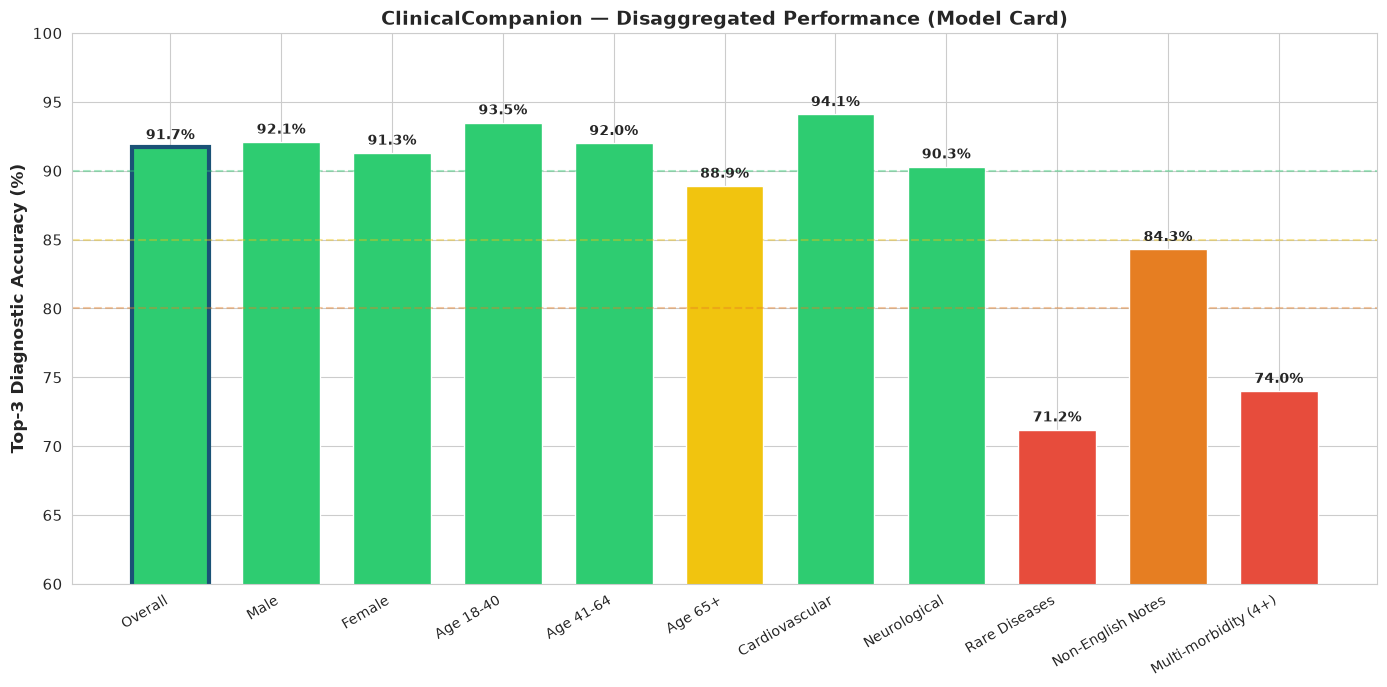


⚠️  SUBGROUPS BELOW 85% THRESHOLD:
  • Rare Diseases: 71.2% (n=1,035) — mitigation required
  • Non-English Notes: 84.3% (n=5,400) — mitigation required
  • Multi-morbidity (4+): 74.0% (n=7,650) — mitigation required
✅ Saved: results/model_card_performance.png


In [16]:
# Step 6b: Create disaggregated performance visualization

fig, ax = plt.subplots(figsize=(14, 7))

def perf_color(v):
    if v >= 90: return '#2ecc71'
    if v >= 85: return '#f1c40f'
    if v >= 80: return '#e67e22'
    return '#e74c3c'

colors = [perf_color(v) for v in accuracy_df['value']]
bars = ax.bar(range(len(accuracy_df)), accuracy_df['value'], color=colors,
              edgecolor='white', width=0.7)

# Highlight the "Overall" bar with a distinct border
for idx, (_, r) in enumerate(accuracy_df.iterrows()):
    if r['subgroup'] == 'Overall':
        bars[idx].set_edgecolor('#1a5276')
        bars[idx].set_linewidth(3)

# Value labels on top of each bar
for idx, v in enumerate(accuracy_df['value']):
    ax.text(idx, v + 0.6, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')

# Reference lines and formatting (provided)
ax.axhline(y=90, color='#2ecc71', ls='--', alpha=0.4)
ax.axhline(y=85, color='#f1c40f', ls='--', alpha=0.4)
ax.axhline(y=80, color='#e67e22', ls='--', alpha=0.4)
ax.set_xticks(range(len(accuracy_df)))
ax.set_xticklabels(accuracy_df['subgroup'], fontsize=10, rotation=30, ha='right')
ax.set_ylabel('Top-3 Diagnostic Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('ClinicalCompanion — Disaggregated Performance (Model Card)', fontsize=14, fontweight='bold')
ax.set_ylim(60, 100)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_card_performance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Subgroups below 85% — these need mitigation before launch
print("\n⚠️  SUBGROUPS BELOW 85% THRESHOLD:")
for _, r in accuracy_df[accuracy_df['value'] < 85].iterrows():
    print(f"  • {r['subgroup']}: {r['value']:.1f}% (n={r['sample_size']:,}) — mitigation required")
print("✅ Saved: results/model_card_performance.png")


---
## Step 7: Monitoring & Incident Response Dashboard

**Time estimate: ~30 minutes**

Create a multi-panel monitoring dashboard that visualizes KPIs, incident taxonomy, and response framework.

*Full monitoring plan goes in `governance_workbook.xlsx` → Sheet "Monitoring & Incidents"*

### 7a. Load monitoring data

🔧 **TODO:** Load the three monitoring data files:
- `monitoring_kpis.csv` — 16 KPI definitions
- `incident_types.csv` — 10 AI-specific incident types
- `severity_levels.csv` — S1-S4 severity levels

Print a brief summary of each (number of KPIs by dimension, number of incident types, severity levels).

In [17]:
# Step 7a: Load monitoring data files

kpi_df = pd.read_csv(DATA_DIR / 'monitoring_kpis.csv')
incident_df = pd.read_csv(DATA_DIR / 'incident_types.csv')
severity_df = pd.read_csv(DATA_DIR / 'severity_levels.csv')

print(f"MONITORING KPIs: {len(kpi_df)} total")
for dim, count in kpi_df['dimension'].value_counts().items():
    print(f"  • {dim:<22}: {count} KPIs")

print(f"\nINCIDENT TYPES: {len(incident_df)} AI-specific categories")
for _, r in incident_df.iterrows():
    print(f"  • {r['incident_id']}: {r['incident_type']} (severity {r['severity_range']})")

print("\nSEVERITY LEVELS:")
for _, r in severity_df.iterrows():
    print(f"  • {r['severity']} ({r['label']:<8}) — response within {r['response_time']}")


MONITORING KPIs: 16 total
  • Clinical Performance  : 5 KPIs
  • Fairness & Bias       : 4 KPIs
  • Operational           : 4 KPIs
  • Data Quality          : 3 KPIs

INCIDENT TYPES: 10 AI-specific categories
  • INC-01: Clinical Hallucination (severity S2-S1)
  • INC-02: Harmful Suggestion (severity S1)
  • INC-03: Bias-Related Harm (severity S2-S1)
  • INC-04: Privacy Breach (severity S1)
  • INC-05: Performance Degradation (severity S3-S2)
  • INC-06: Adversarial Manipulation (severity S2-S1)
  • INC-07: Vendor Service Disruption (severity S3-S2)
  • INC-08: Data Pipeline Failure (severity S1)
  • INC-09: Unauthorized Access (severity S2-S1)
  • INC-10: Regulatory Non-Compliance (severity S3-S2)

SEVERITY LEVELS:
  • S1 (Critical) — response within Immediate (30 min)
  • S2 (High    ) — response within Within 2 hours
  • S3 (Medium  ) — response within Within 24 hours
  • S4 (Low     ) — response within Within 1 week


### 7b. Create monitoring dashboard (4 panels)

🔧 **TODO:** Create a 2×2 dashboard with these panels:

**Panel 1 (top-left): KPI Status vs. Targets**
- Select 6 key KPIs and show current values as bars
- Overlay target values as dashed horizontal lines
- Color: green if meeting target, red if below

**Panel 2 (top-right): Incident Distribution**
- Pie chart showing distribution across severity levels (S1-S4)

**Panel 3 (bottom-left): Response Time SLAs**
- Horizontal bar chart showing response time for each severity level
- Use log scale for x-axis (ranges from 0.5h to 168h)
- Color-coded by severity (red→green)

**Panel 4 (bottom-right): Monitoring Coverage**
- Bar chart showing number of KPIs per dimension
- Shows which areas have more/less monitoring coverage

Save as `results/monitoring_dashboard.png`.

*Hint: Use `plt.subplots(2, 2, figsize=(16, 12))` for the 4-panel layout*

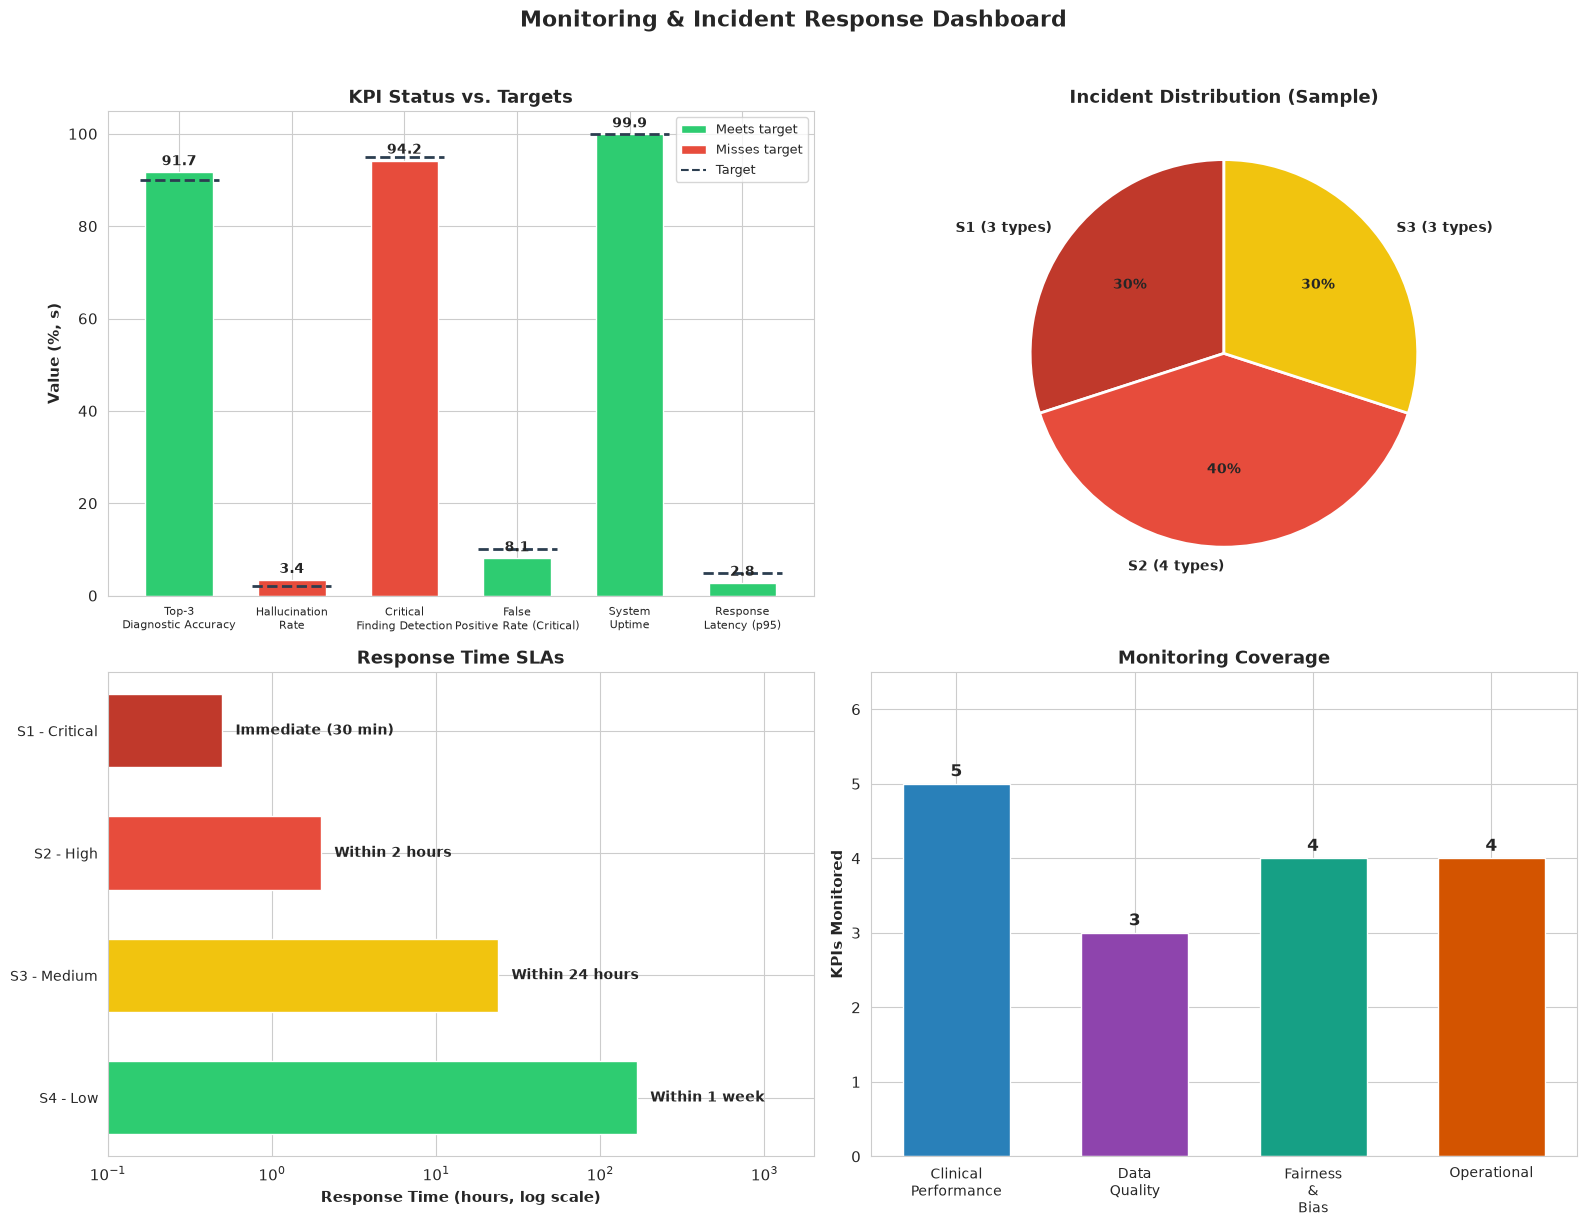

✅ Saved: results/monitoring_dashboard.png


In [18]:
# Step 7b: Create 4-panel monitoring dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Panel 1 (top-left): KPI Status vs. Targets ---
ax = axes[0, 0]
# Select 6 key KPIs to display
kpis_show = ['Top-3 Diagnostic Accuracy', 'Hallucination Rate', 'Critical Finding Detection',
             'False Positive Rate (Critical)', 'System Uptime', 'Response Latency (p95)']
# Current values (from performance_metrics.csv / system spec) and targets
# (current, target, lower_is_better)
kpi_status = {
    'Top-3 Diagnostic Accuracy':      (91.7, 90.0, False),
    'Hallucination Rate':             (3.4,  2.0,  True),
    'Critical Finding Detection':     (94.2, 95.0, False),
    'False Positive Rate (Critical)': (8.1,  10.0, True),
    'System Uptime':                  (99.9, 99.9, False),
    'Response Latency (p95)':         (2.8,  5.0,  True),
}
currents = [kpi_status[k][0] for k in kpis_show]
targets = [kpi_status[k][1] for k in kpis_show]
meets = [(c <= t) if low else (c >= t)
         for (c, t, low) in (kpi_status[k] for k in kpis_show)]
colors = ['#2ecc71' if m else '#e74c3c' for m in meets]

bars = ax.bar(range(len(kpis_show)), currents, color=colors, edgecolor='white', width=0.6)
for idx, (c, t) in enumerate(zip(currents, targets)):
    ax.plot([idx - 0.35, idx + 0.35], [t, t], color='#2c3e50', ls='--', lw=2)
    ax.text(idx, c + 1.5, f"{c}", ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(kpis_show)))
ax.set_xticklabels([k.replace(' ', '\n', 1) for k in kpis_show], fontsize=8)
ax.set_ylabel('Value (%, s)', fontweight='bold')
ax.legend(handles=[mpatches.Patch(fc='#2ecc71', label='Meets target'),
                   mpatches.Patch(fc='#e74c3c', label='Misses target'),
                   plt.Line2D([0], [0], color='#2c3e50', ls='--', label='Target')],
          fontsize=9)
ax.set_title('KPI Status vs. Targets', fontsize=13, fontweight='bold')

# --- Panel 2 (top-right): Incident Distribution ---
ax = axes[0, 1]
# Distribution of the 10 incident types by their typical (modal) severity
typical_sev = incident_df['severity_range'].str.split('-').str[0]
sev_dist = typical_sev.value_counts().reindex(['S1', 'S2', 'S3', 'S4']).dropna().astype(int)
pie_colors = {'S1': '#c0392b', 'S2': '#e74c3c', 'S3': '#f1c40f', 'S4': '#2ecc71'}
ax.pie(sev_dist, labels=[f"{s} ({n} types)" for s, n in sev_dist.items()],
       colors=[pie_colors[s] for s in sev_dist.index],
       autopct='%1.0f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 10, 'fontweight': 'bold'})
ax.set_title('Incident Distribution (Sample)', fontsize=13, fontweight='bold')

# --- Panel 3 (bottom-left): Response Time SLAs ---
ax = axes[1, 0]
sev_colors = ['#c0392b', '#e74c3c', '#f1c40f', '#2ecc71']
sev_names = [f"{r['severity']} - {r['label']}" for _, r in severity_df.iterrows()]

ax.barh(range(len(severity_df)), severity_df['response_hours'],
        color=sev_colors, edgecolor='white', height=0.6)
ax.set_xscale('log')
ax.set_yticks(range(len(severity_df)))
ax.set_yticklabels(sev_names, fontsize=10)
for idx, (_, r) in enumerate(severity_df.iterrows()):
    ax.text(r['response_hours'] * 1.2, idx, r['response_time'],
            va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0.1, 2000)

ax.set_xlabel('Response Time (hours, log scale)', fontweight='bold')
ax.set_title('Response Time SLAs', fontsize=13, fontweight='bold')
ax.invert_yaxis()

# --- Panel 4 (bottom-right): Monitoring Coverage by Dimension ---
ax = axes[1, 1]
dim_counts = kpi_df.groupby('dimension').size().reset_index(name='count')

dim_colors = ['#2980b9', '#8e44ad', '#16a085', '#d35400']
bars = ax.bar(range(len(dim_counts)), dim_counts['count'],
              color=dim_colors[:len(dim_counts)], edgecolor='white', width=0.6)
for idx, n in enumerate(dim_counts['count']):
    ax.text(idx, n + 0.1, str(n), ha='center', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(dim_counts)))
ax.set_xticklabels(dim_counts['dimension'].str.replace(' ', '\n'), fontsize=10)
ax.set_ylim(0, dim_counts['count'].max() + 1.5)

ax.set_ylabel('KPIs Monitored', fontweight='bold')
ax.set_title('Monitoring Coverage', fontsize=13, fontweight='bold')

# Save
plt.suptitle('Monitoring & Incident Response Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'monitoring_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/monitoring_dashboard.png")


---
## Step 8: Executive Summary Dashboard

**Time estimate: ~15 minutes**

Create a board-ready visualization summarizing the overall governance readiness.

*Full executive summary goes in `governance_workbook.xlsx` → Sheet "Executive Summary"*

### 8a. Create executive readiness dashboard

🔧 **TODO:** Create a figure with two panels:

**Left — Compliance Readiness Bars:**
- Show readiness percentages for 6 areas: EU AI Act Conformity, MDR CE Marking, GDPR DPIA, Technical Docs, Post-Market Monitoring, Human Oversight
- Assign realistic readiness percentages based on your analysis throughout this notebook
- Color-code: green (≥75%), yellow (50-74%), red (<50%)
- Label each bar with "XX% — Risk Level"

**Right — Governance Readiness Gauge:**
- Calculate an overall governance readiness score (weighted average of the 6 areas)
- Display as a semi-circular gauge (0-100%)
- Color bands: red (0-40%), yellow (40-70%), green (70-90%), dark green (90-100%)

Save as `results/executive_dashboard.png`.

*Hint: You can create a gauge using `annotate()` with an arrow on a subplot with `set_aspect('equal')`*

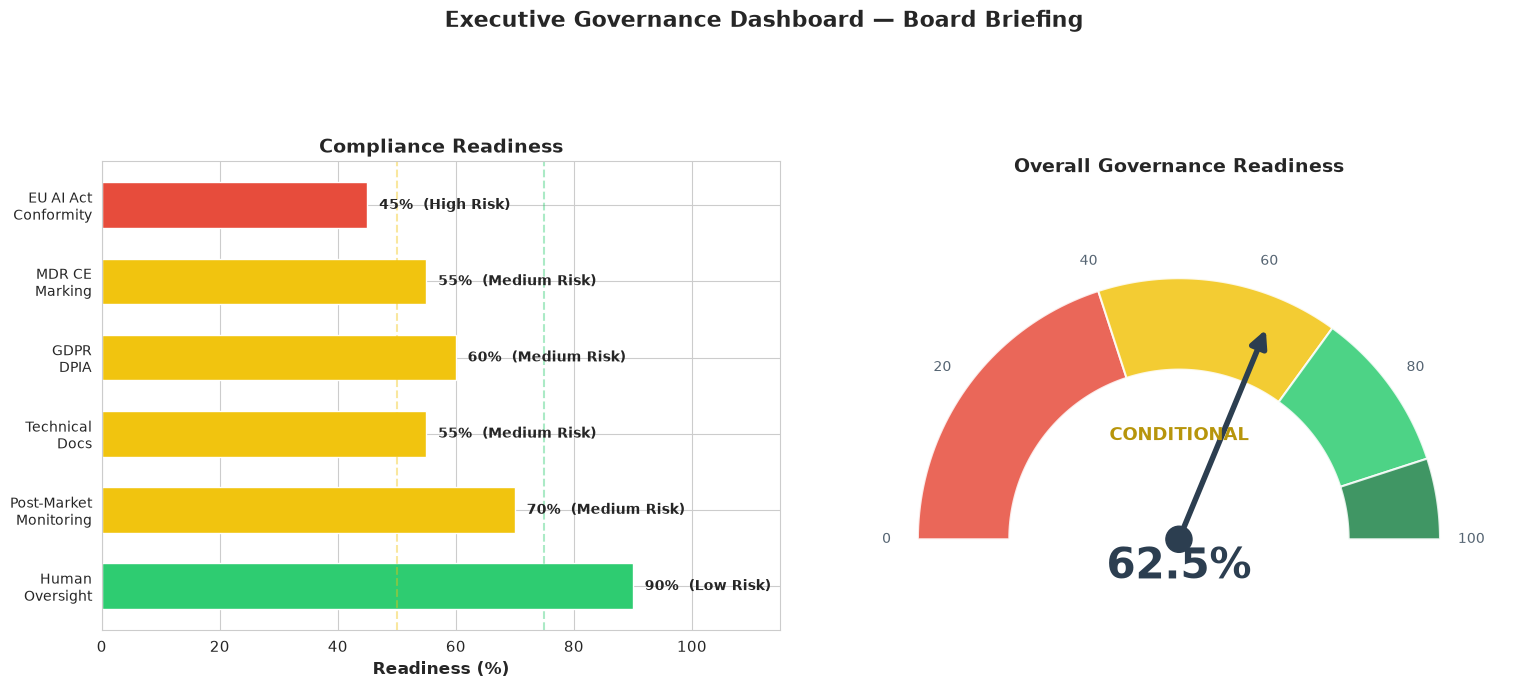

✅ Saved: results/executive_dashboard.png

Overall governance readiness: 62.5% → CONDITIONAL launch recommendation


In [19]:
# Step 8a: Create executive readiness dashboard

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Compliance Readiness Bars ---
areas = ['EU AI Act\nConformity', 'MDR CE\nMarking', 'GDPR\nDPIA',
         'Technical\nDocs', 'Post-Market\nMonitoring', 'Human\nOversight']

# Readiness estimates grounded in the Step 2-7 analysis:
#  EU AI Act Conformity 45% — 1 Critical + 5 High gaps open; Notified Body not engaged
#  MDR CE Marking      55% — application submitted, awaiting Notified Body
#  GDPR DPIA           60% — v1 complete; needs update for foundation model flows + TIA
#  Technical Docs      55% — Art. 11 package in progress; audit-trail gaps (Art. 12)
#  Post-Market Monitor 70% — 16-KPI framework designed; implementation pending
#  Human Oversight     90% — Art. 14 compliant (physician-in-the-loop + override)
readiness = [45, 55, 60, 55, 70, 90]

def ready_color(p):
    return '#2ecc71' if p >= 75 else ('#f1c40f' if p >= 50 else '#e74c3c')
def ready_label(p):
    return 'Low Risk' if p >= 75 else ('Medium Risk' if p >= 50 else 'High Risk')

ax1.barh(range(len(areas)), readiness,
         color=[ready_color(p) for p in readiness], edgecolor='white', height=0.6)
ax1.set_yticks(range(len(areas)))
ax1.set_yticklabels(areas, fontsize=10)
for idx, p in enumerate(readiness):
    ax1.text(p + 2, idx, f"{p}%  ({ready_label(p)})", va='center',
             fontsize=10, fontweight='bold')
ax1.axvline(x=75, color='#2ecc71', ls='--', alpha=0.4)
ax1.axvline(x=50, color='#f1c40f', ls='--', alpha=0.4)

ax1.set_xlabel('Readiness (%)', fontsize=12, fontweight='bold')
ax1.set_title('Compliance Readiness', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 115)
ax1.invert_yaxis()

# --- RIGHT PANEL: Governance Readiness Gauge ---
score = np.mean(readiness)

# Color bands drawn as a semi-circular ring (π = 0%, 0 = 100%)
bands = [(0, 40, '#e74c3c'), (40, 70, '#f1c40f'), (70, 90, '#2ecc71'), (90, 100, '#1e8449')]
theta_for = lambda pct: np.pi * (1 - pct / 100)
for lo, hi, color in bands:
    theta = np.linspace(theta_for(hi), theta_for(lo), 50)
    ax2.fill(np.concatenate([0.65 * np.cos(theta), 1.0 * np.cos(theta[::-1])]),
             np.concatenate([0.65 * np.sin(theta), 1.0 * np.sin(theta[::-1])]),
             color=color, alpha=0.85, edgecolor='white', lw=1.5)

# Scale labels
for pct in [0, 20, 40, 60, 80, 100]:
    t = theta_for(pct)
    ax2.text(1.12 * np.cos(t), 1.12 * np.sin(t), f"{pct}", ha='center', va='center',
             fontsize=10, color='#566573')

# Needle pointing at the overall score
t = theta_for(score)
ax2.annotate('', xy=(0.88 * np.cos(t), 0.88 * np.sin(t)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='-|>', color='#2c3e50', lw=4,
                             mutation_scale=25))
ax2.add_patch(plt.Circle((0, 0), 0.05, color='#2c3e50', zorder=5))

# Score text
ax2.text(0, -0.15, f"{score:.1f}%", ha='center', fontsize=30, fontweight='bold',
         color='#2c3e50')
ax2.text(0, 0.38, 'CONDITIONAL', ha='center', fontsize=13, fontweight='bold',
         color='#b7950b')

ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-0.2, 1.3)
ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title('Overall Governance Readiness', fontsize=14, fontweight='bold', pad=20)

# Save
plt.suptitle('Executive Governance Dashboard — Board Briefing', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'executive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/executive_dashboard.png")

print(f"\nOverall governance readiness: {score:.1f}% → CONDITIONAL launch recommendation")


---
## Deliverables Checklist

Before submitting, verify you have completed both deliverables:

### Notebook (this file)
- [ ] Step 1: System spec exploration — key facts extracted
- [ ] Step 2: EU AI Act classification — decision tree + gap analysis
- [ ] Step 3: Risk assessment — summary statistics + mitigation analysis
- [ ] Step 4: Risk heatmap + mitigation comparison — saved to `results/`
- [ ] Step 5: Vendor evaluation chart — saved to `results/`
- [ ] Step 6: Model card performance chart — saved to `results/`
- [ ] Step 7: Monitoring dashboard (4 panels) — saved to `results/`
- [ ] Step 8: Executive dashboard — saved to `results/`

### Workbook (`governance_workbook.xlsx`)
- [ ] Sheet 1: EU AI Act Classification — classification + compliance gap table
- [ ] Sheet 2: Risk Register — all 8 risks with scores and mitigations
- [ ] Sheet 3: Vendor Evaluation — category scores + recommendation
- [ ] Sheet 4: Model Card — full model card content
- [ ] Sheet 5: Monitoring & Incidents — KPI table + incident response plan
- [ ] Sheet 6: Executive Summary — board-ready narrative

### Results folder
Verify these 6 files exist in `results/`:
- [ ] `risk_heatmap.png`
- [ ] `risk_mitigation_comparison.png`
- [ ] `vendor_evaluation_chart.png`
- [ ] `model_card_performance.png`
- [ ] `monitoring_dashboard.png`
- [ ] `executive_dashboard.png`